### Problem: Predicting a student's Mental_Health_Score (a continuous score from ~3 to ~10) using their social media habits, study time, sleep, physical activity, and stress level. This is a regression problem since the target is a number, not a category.

### Dataset: Student_Social_Media_And_Mental_Health_Impact.csv — 5,000 students, 13 columns covering demographics (Age, Gender, Country), platform usage (Avg_Daily_Usage_Hours, Daily_Unlocks, Most_Used_Platform), lifestyle (Study_Hours, Sleep_Hours_Per_Night, Physical_Activity_Hours), and Stress_Level.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv('Student Social Media And Mental Health Impact.csv')

In [7]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [8]:
df.shape

(5000, 13)

In [9]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


# Exploratory Data Analysis

In [11]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(2)

In [13]:
# Observation : We have no null values and only 2 duplicate rows

In [15]:
df[df.duplicated(keep=False)]

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
886,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
1870,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5
2405,19,Female,Other,Undergraduate,LinkedIn,Education,6.1,202,1.0,2.1,5.8,High,4.1
2463,21,Male,USA,Undergraduate,Snapchat,Entertainment,3.9,126,5.1,2.6,7.1,Low,7.5


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [17]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [18]:
# Observation : 
#1 the age column is very clean and the age is between [18,24] this is usually the range of College Students
#2 realistic values in Avg_Daily_Usage_Hours	
#3 Study_Hours looks good as well no mischievous values 
#4 Physical_Activity_Hours column has negative minimum values which is not possible as data is in unit of time and time cannot be -ve
#5 all the rest Numerical Features Look Good

In [24]:
for i in df.select_dtypes(include=['object']).columns:
    print(df[i].nunique())
    print(df[i].unique())
    print(df[i].value_counts())
    print('=======================================================')

2
['Male' 'Female']
Gender
Male      2635
Female    2365
Name: count, dtype: int64
111
['Other' 'Canada' 'USA' 'India' 'Australia' 'UK' 'Germany' 'Bangladesh'
 'Brazil' 'Japan' 'South Korea' 'France' 'Spain' 'Italy' 'Mexico' 'Russia'
 'China' 'Sweden' 'Norway' 'Denmark' 'Netherlands' 'Belgium' 'Switzerland'
 'Austria' 'Portugal' 'Greece' 'Ireland' 'New Zealand' 'Singapore'
 'Malaysia' 'Thailand' 'Vietnam' 'Philippines' 'Indonesia' 'Taiwan'
 'Hong Kong' 'Turkey' 'Israel' 'UAE' 'Egypt' 'Morocco' 'South Africa'
 'Nigeria' 'Kenya' 'Ghana' 'Argentina' 'Chile' 'Colombia' 'Peru'
 'Venezuela' 'Ecuador' 'Uruguay' 'Paraguay' 'Bolivia' 'Costa Rica'
 'Panama' 'Jamaica' 'Trinidad' 'Bahamas' 'Iceland' 'Finland' 'Poland'
 'Romania' 'Hungary' 'Czech Republic' 'Slovakia' 'Croatia' 'Serbia'
 'Slovenia' 'Bulgaria' 'Estonia' 'Latvia' 'Lithuania' 'Ukraine' 'Moldova'
 'Belarus' 'Kazakhstan' 'Uzbekistan' 'Kyrgyzstan' 'Tajikistan' 'Armenia'
 'Georgia' 'Azerbaijan' 'Cyprus' 'Malta' 'Luxembourg' 'Monaco' 'Andor

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

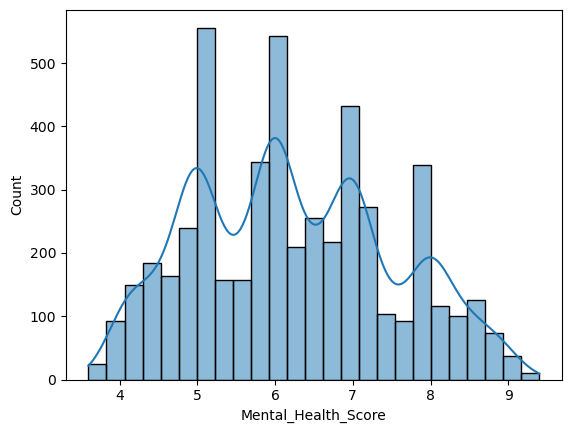

In [26]:
sns.histplot(x = df['Mental_Health_Score'],kde=True)

In [27]:
df['Mental_Health_Score'].skew()

np.float64(0.2065673061644126)

<Axes: xlabel='Age', ylabel='Count'>

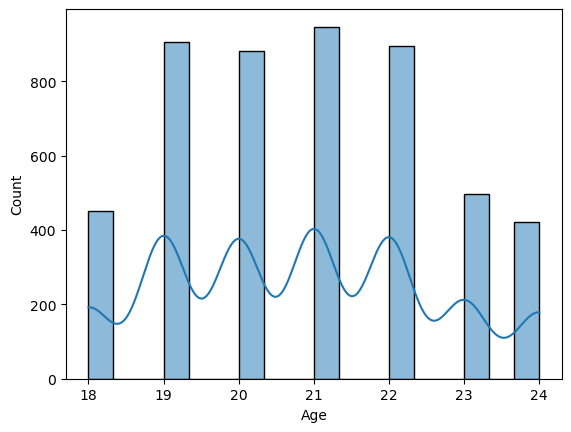

In [30]:
sns.histplot(x=df['Age'],kde=True)

In [31]:
df['Age'].skew()

np.float64(0.15532509166166805)

In [33]:
df['Age'].value_counts()

Age
21    947
19    906
22    896
20    883
23    496
18    450
24    422
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='Mental_Health_Score'>

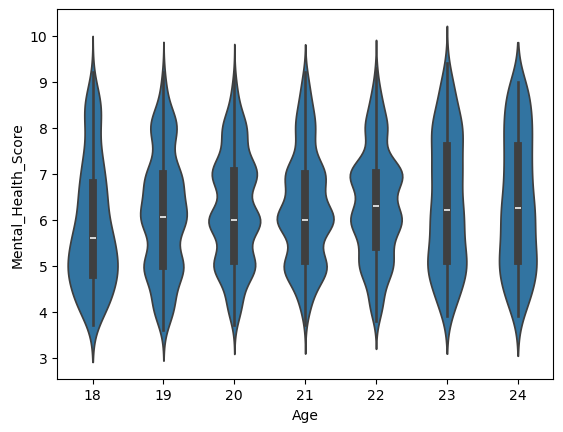

In [34]:
sns.violinplot(x = df['Age'],y= df['Mental_Health_Score'])

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Count'>

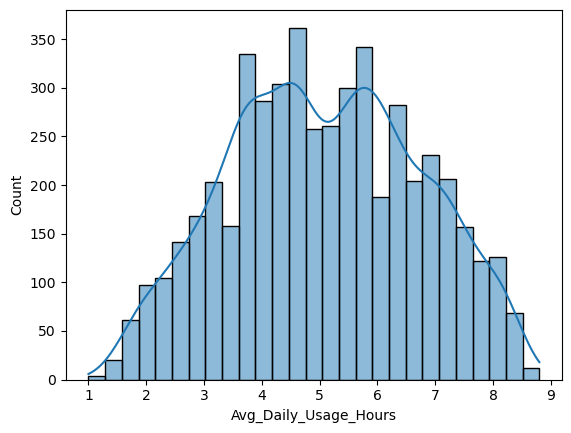

In [36]:
sns.histplot(x = df['Avg_Daily_Usage_Hours'],kde=True)

In [37]:
df['Avg_Daily_Usage_Hours'].skew()

np.float64(0.00560613955389822)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

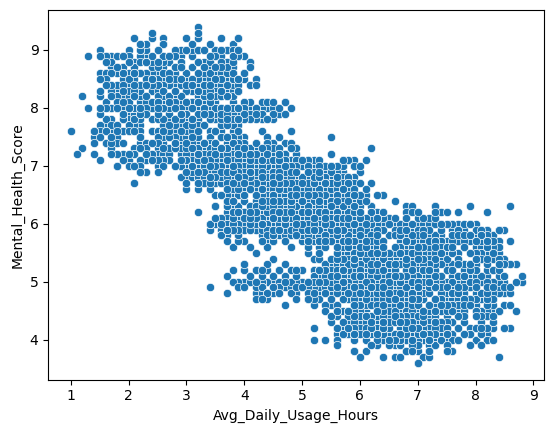

In [38]:
sns.scatterplot(x = df['Avg_Daily_Usage_Hours'] , y = df['Mental_Health_Score'])

<Axes: xlabel='Daily_Unlocks', ylabel='Count'>

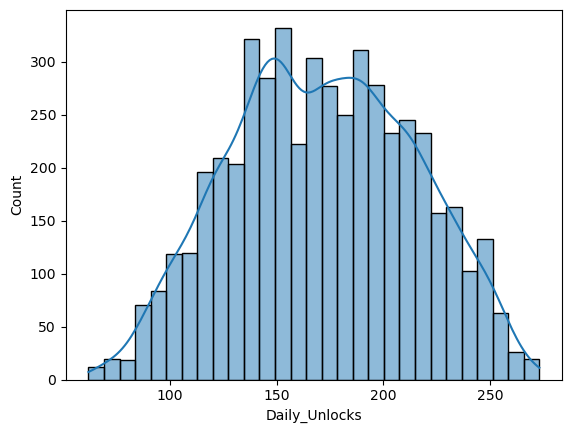

In [41]:
sns.histplot(x = df['Daily_Unlocks'],kde = True)

In [42]:
df['Daily_Unlocks'].skew()

np.float64(0.002351349938582424)

<Axes: xlabel='Daily_Unlocks', ylabel='Mental_Health_Score'>

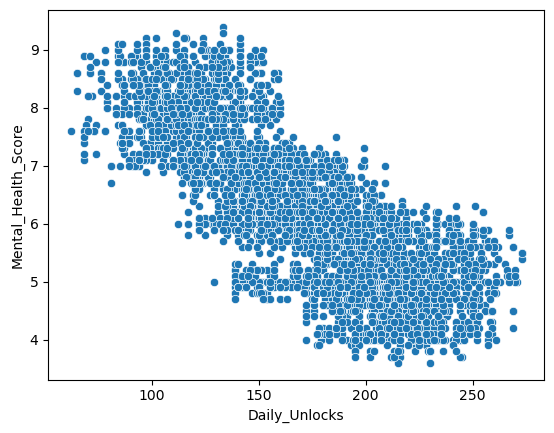

In [43]:
sns.scatterplot(x = df['Daily_Unlocks'] , y= df['Mental_Health_Score'])

<Axes: xlabel='Study_Hours', ylabel='Count'>

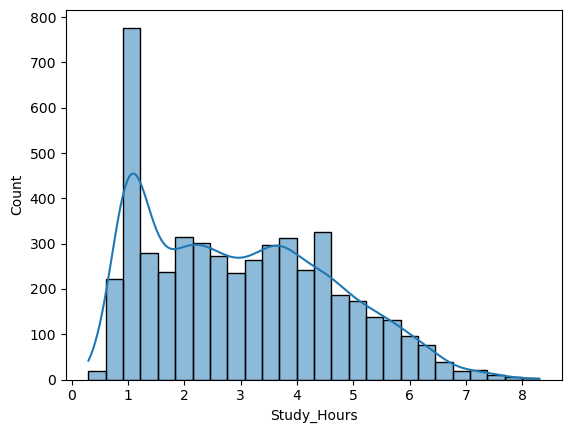

In [45]:
sns.histplot(x=df['Study_Hours'],kde=True)

In [46]:
df['Study_Hours'].skew()

np.float64(0.4358185156222703)

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

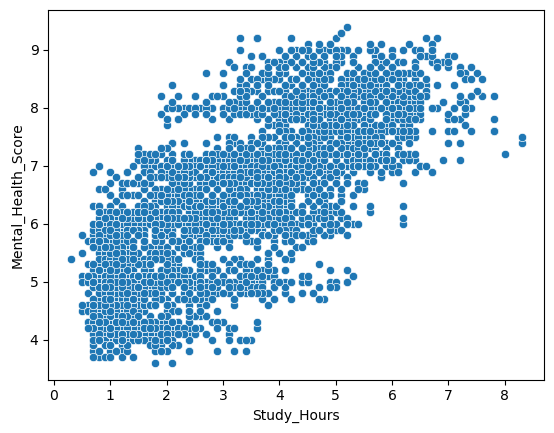

In [47]:
sns.scatterplot(x = df['Study_Hours'] , y = df['Mental_Health_Score'])

<Axes: xlabel='Physical_Activity_Hours', ylabel='Count'>

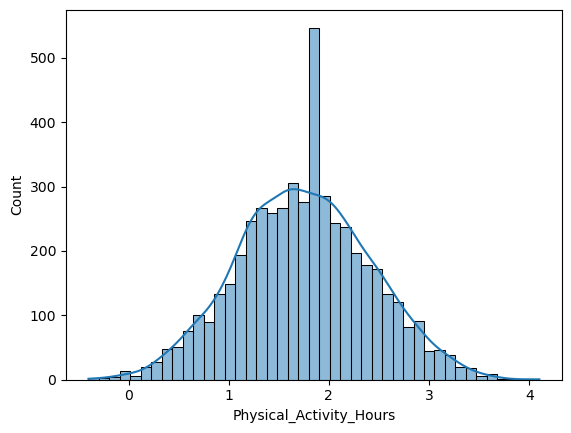

In [49]:
sns.histplot(x=df['Physical_Activity_Hours'],kde=True)

In [50]:
df['Physical_Activity_Hours'].skew()

np.float64(0.0399705642623147)

<Axes: xlabel='Physical_Activity_Hours', ylabel='Mental_Health_Score'>

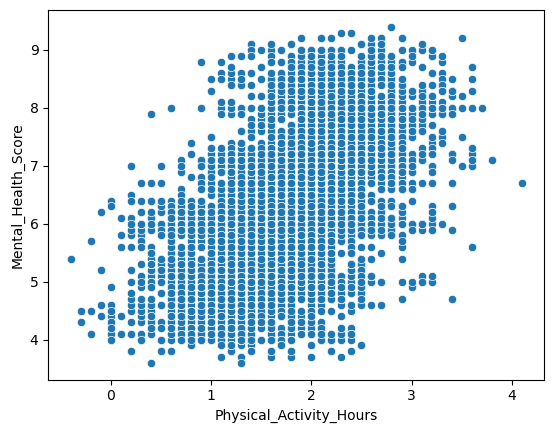

In [51]:
sns.scatterplot(x = df['Physical_Activity_Hours'] , y = df['Mental_Health_Score'])

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Count'>

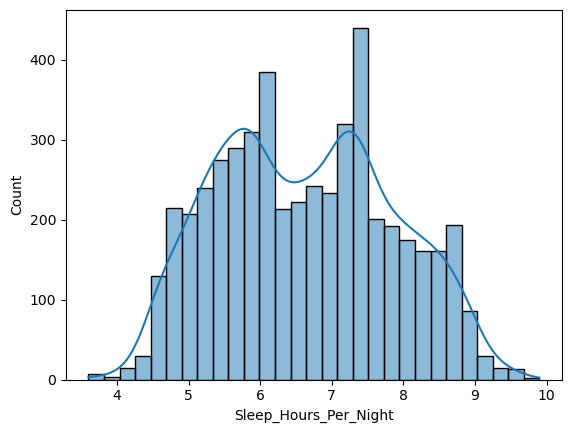

In [53]:
sns.histplot(x=df['Sleep_Hours_Per_Night'],kde=True)

In [54]:
df['Sleep_Hours_Per_Night'].skew()

np.float64(0.12404965689127949)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

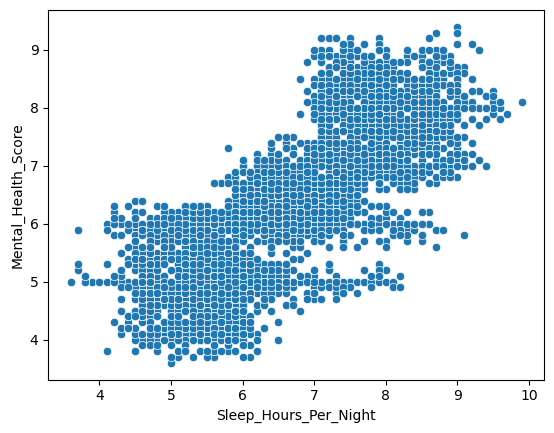

In [55]:
sns.scatterplot(x=df['Sleep_Hours_Per_Night'] , y= df['Mental_Health_Score'])

<Axes: >

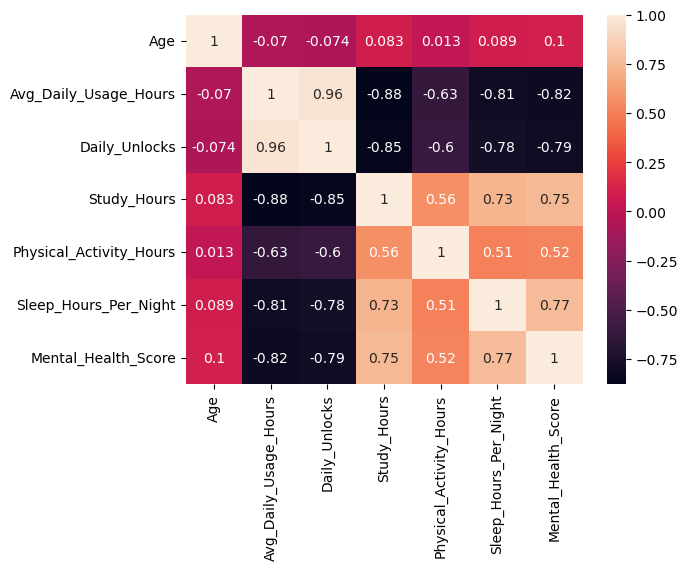

In [57]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [58]:
df.select_dtypes(include=['object']).columns

Index(['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Stress_Level'],
      dtype='object')

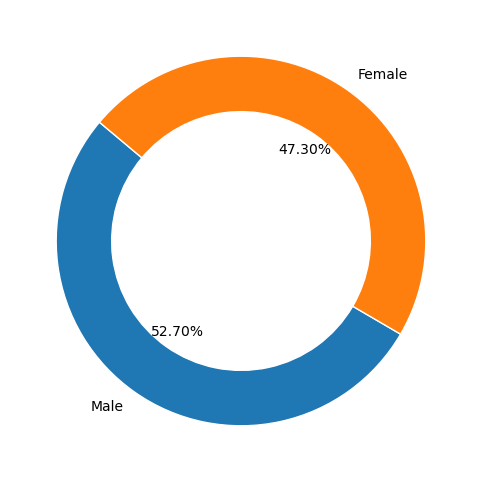

In [65]:
plt.figure(figsize=(6, 6))
plt.pie(
    df['Gender'].value_counts(),
    labels=df['Gender'].unique(),
    autopct='%0.2f%%', 
    startangle=140,
    wedgeprops=dict(width=0.3, edgecolor='w') 
)
plt.show()

<Axes: xlabel='Gender', ylabel='Mental_Health_Score'>

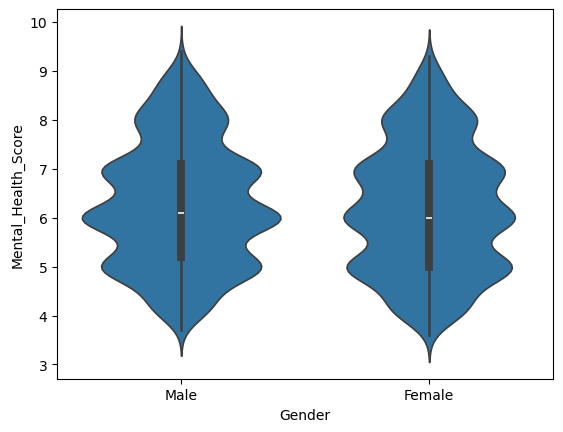

In [66]:
sns.violinplot(x = df['Gender'] , y = df['Mental_Health_Score'])

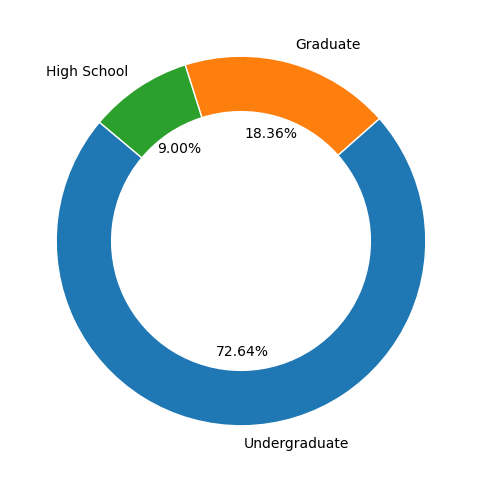

In [72]:
plt.figure(figsize=(6, 6))
plt.pie(
    df['Academic_Level'].value_counts(),
    labels=df['Academic_Level'].unique(),
    autopct='%0.2f%%', 
    startangle=140,
    wedgeprops=dict(width=0.3, edgecolor='w') 
)
plt.show()

<Axes: xlabel='Academic_Level', ylabel='Mental_Health_Score'>

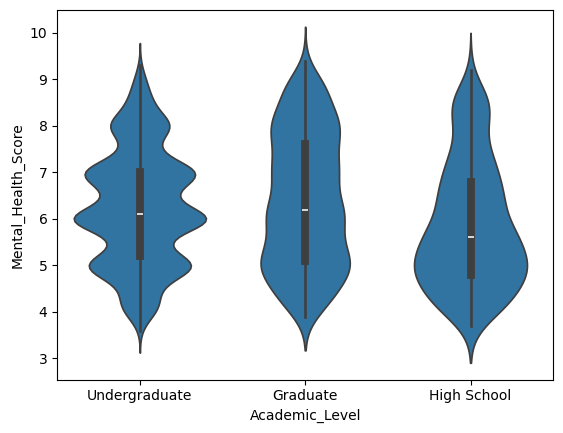

In [73]:
sns.violinplot(x = df['Academic_Level'] , y = df['Mental_Health_Score'])

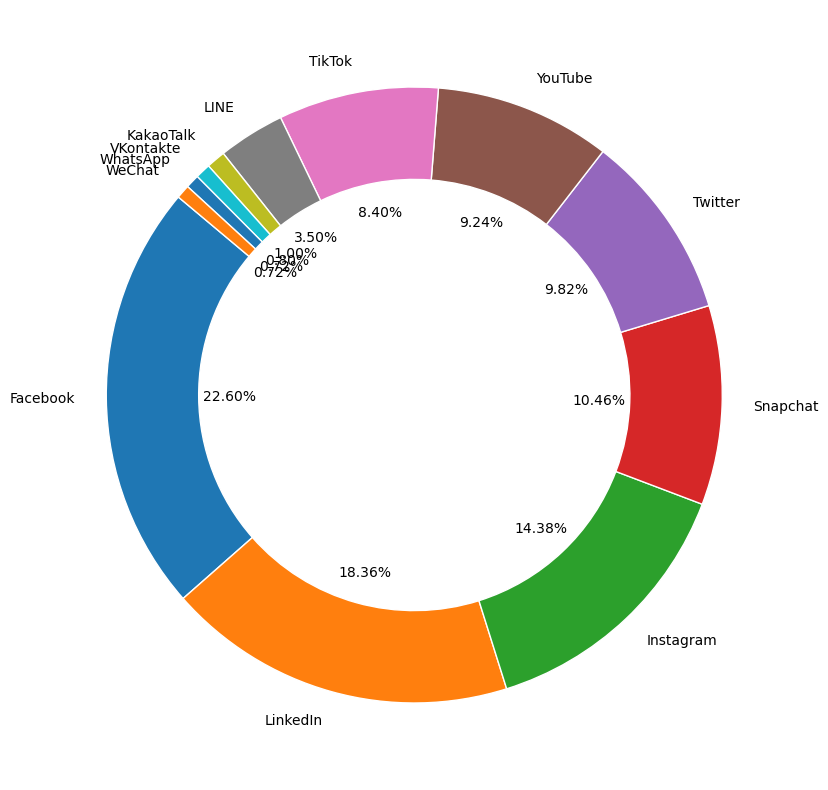

In [75]:
plt.figure(figsize=(10, 10))
plt.pie(
    df['Most_Used_Platform'].value_counts(),
    labels=df['Most_Used_Platform'].unique(),
    autopct='%0.2f%%', 
    startangle=140,
    wedgeprops=dict(width=0.3, edgecolor='w') 
)
plt.show()

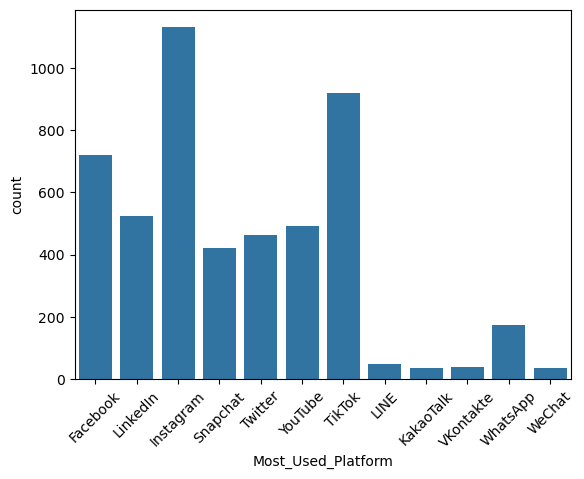

In [82]:
sns.countplot(x = df['Most_Used_Platform'])
plt.xticks(rotation=45)
plt.show()

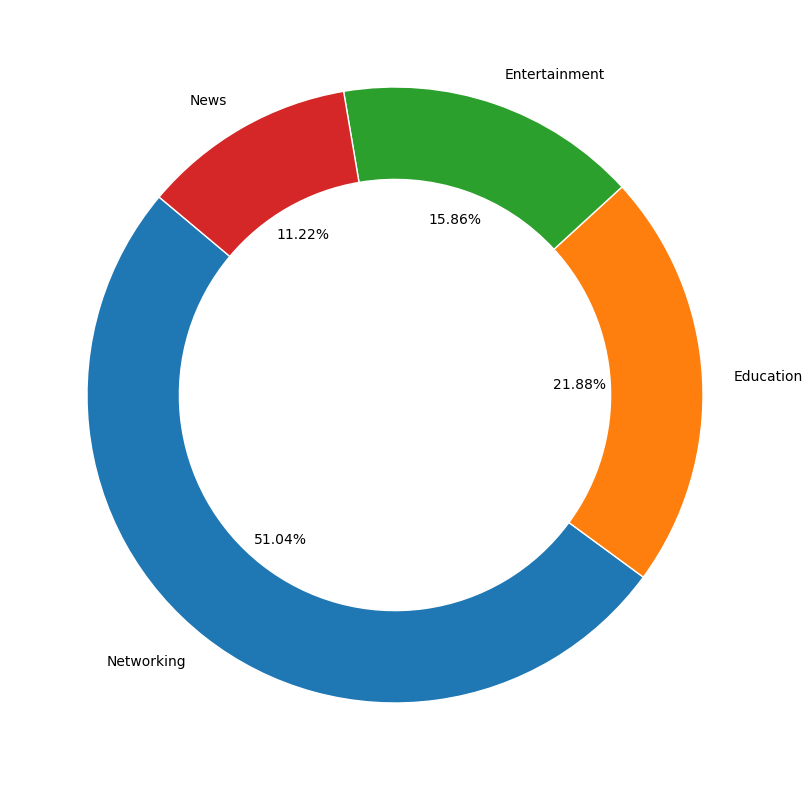

In [77]:

plt.figure(figsize=(10, 10))
plt.pie(
    df['Purpose_Of_Use'].value_counts(),
    labels=df['Purpose_Of_Use'].unique(),
    autopct='%0.2f%%', 
    startangle=140,
    wedgeprops=dict(width=0.3, edgecolor='w') 
)
plt.show()

<Axes: xlabel='Purpose_Of_Use', ylabel='Mental_Health_Score'>

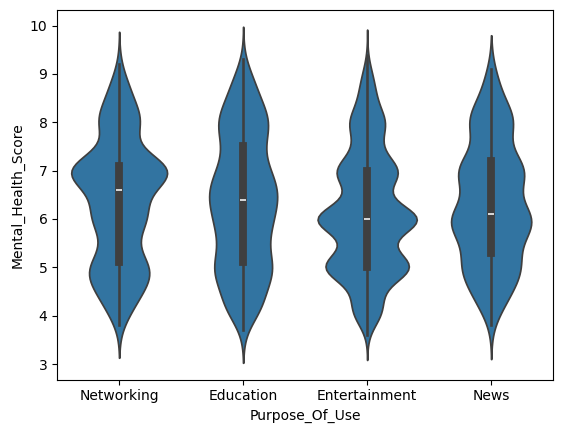

In [78]:
sns.violinplot(x = df['Purpose_Of_Use'] , y = df['Mental_Health_Score'])

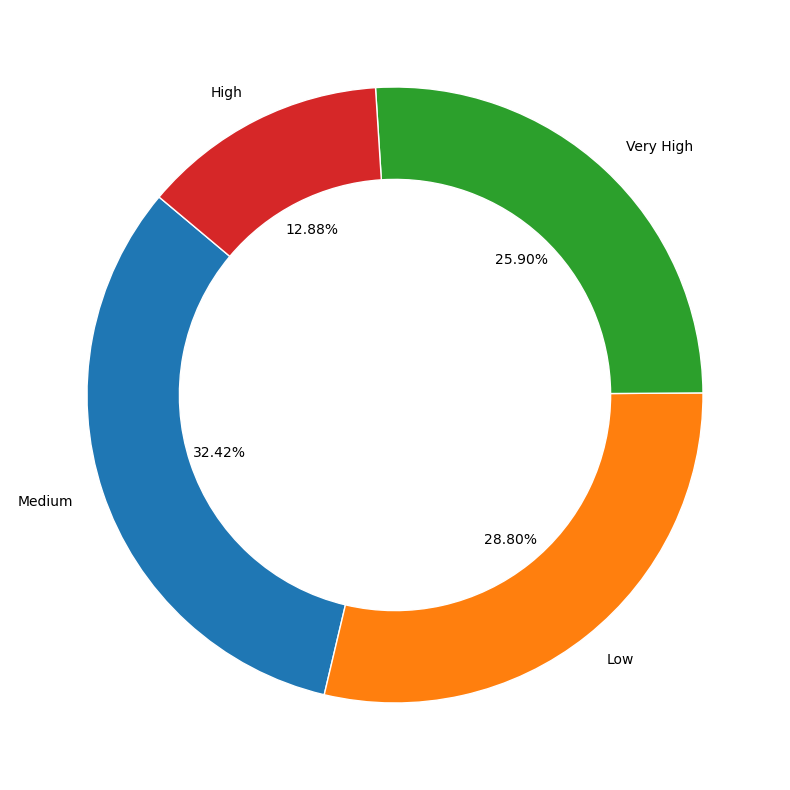

In [83]:
plt.figure(figsize=(10, 10))
plt.pie(
    df['Stress_Level'].value_counts(),
    labels=df['Stress_Level'].unique(),
    autopct='%0.2f%%', 
    startangle=140,
    wedgeprops=dict(width=0.3, edgecolor='w') 
)
plt.show()

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

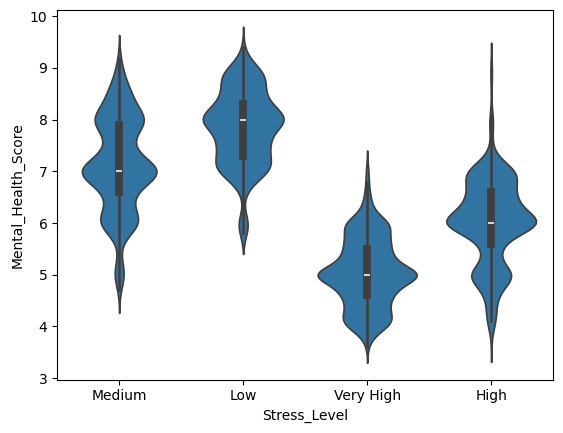

In [84]:
sns.violinplot(x = df['Stress_Level'] , y = df['Mental_Health_Score'])

In [91]:
num_df = df.select_dtypes(include=['number'])
Q1 = num_df.quantile(.25)
Q3 = num_df.quantile(.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = (num_df < lower) | (num_df > upper)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [92]:
# 2 outliers  0.004%  -> Study_Hours
# 22 outliers 0.044% --> Physical_Activity_Hours

In [93]:
# As the Outliers are very Low i have decided not to work on them immedietly. as the constitute very less percentage
# compared to overall

# Data Cleaning

In [94]:
# Two real issues : 
#1 Duplicates
#2 Minimum Value of Physical_Activity_Hours is Negetive 


In [98]:
#1 Duplicates : As Observed during EDA there are 2 Duplicate Rows

In [95]:
df.duplicated().sum()

np.int64(2)

In [96]:
df.drop_duplicates(inplace=True)

In [97]:
df.duplicated().sum()

np.int64(0)

In [99]:
#2 Minimum Value of Physical_Activity_Hours is Negetive 

In [100]:
df['Physical_Activity_Hours'].describe()

count    4998.000000
mean        1.750760
std         0.668406
min        -0.400000
25%         1.300000
50%         1.700000
75%         2.200000
max         4.100000
Name: Physical_Activity_Hours, dtype: float64

In [102]:
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)

In [103]:
df['Physical_Activity_Hours'].describe()

count    4998.000000
mean        1.751160
std         0.667282
min         0.000000
25%         1.300000
50%         1.700000
75%         2.200000
max         4.100000
Name: Physical_Activity_Hours, dtype: float64

📌 Why clip(lower=0) and not dropping the row: the rest of that student's data (age, study hours, stress level, etc.) is still valid and useful — throwing away the whole row over one bad value wastes good data. Clipping caps the impossible value at the nearest realistic one (0 hours) without discarding everything else about that student.

We're not dropping any columns either — every column here has a plausible reason to matter for predicting mental health, and we already confirmed none of them are empty or constant.

# Discussion On skewness

In [104]:
num_cols = df.select_dtypes(include='number')
num_cols.skew()
# near to 0 -> Centralized (0.01, 0.002)
# negative -> Left Skewed (-1.56)
# poistive (greater than 0) -> Right Skewed (1.256)

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [105]:
# The Only Heavily Skewed Column is Study_Hours which has a high Corelation with Score So we can use Power Transformers

What skewness is: a measure of how lopsided a numeric column's distribution is. A value near 0 means roughly symmetric (bell-shaped); a large positive or negative value means the data leans heavily to one side, with a long tail.

Why it matters: models like Linear Regression assume features are roughly well-behaved. A heavily skewed column (think: a long tail of extreme values) can quietly drag the model's predictions in that direction. Tree-based models like Random Forest don't care about skew — but since we're also training a Linear Regression baseline, it will be  worth fixing.

# Feature Engineering

- Country has 111 unique values in this dataset — one-hot encoding that directly would add 110+ mostly-empty columns (Sparse Matrix), which hurts the model far more than it helps (this is called high cardinality)(Curse of Dimentionality).
- Dropping Country entirely throws away real signal — a student's country genuinely correlates with things like internet access, culture, and sleep norms, education System etc

In [126]:
x = df['Country'].value_counts() <= 10
print(x[x].index)
print(x[x].shape)


Index(['Uzbekistan', 'Afghanistan', 'Qatar', 'Sweden', 'Norway', 'Egypt',
       'Cyprus', 'Paraguay', 'Moldova', 'Romania', 'Argentina', 'Andorra',
       'Georgia', 'Vietnam', 'Costa Rica', 'Lithuania', 'Latvia', 'Belgium',
       'Czech Republic', 'North Macedonia', 'Lebanon', 'Iraq', 'Trinidad',
       'Panama', 'Greece', 'Peru', 'South Africa', 'Morocco', 'Ukraine',
       'Hong Kong', 'Albania', 'Vatican City', 'San Marino', 'Monaco',
       'Tajikistan', 'Nigeria', 'Kazakhstan', 'Slovakia', 'Estonia', 'Hungary',
       'Austria', 'Bhutan', 'Portugal', 'Bahamas', 'Philippines', 'Indonesia',
       'Jordan', 'Oman', 'Bahrain', 'Taiwan', 'Kosovo', 'Chile', 'Venezuela',
       'Israel', 'Liechtenstein', 'Luxembourg', 'Azerbaijan', 'Ghana',
       'Bulgaria', 'Malta', 'Jamaica', 'Iceland', 'Uruguay', 'Ecuador',
       'Bolivia', 'Kenya', 'Belarus', 'Thailand', 'Syria', 'Yemen', 'Slovenia',
       'Serbia', 'Kyrgyzstan', 'Montenegro', 'Armenia', 'Kuwait', 'Colombia',
       'Bosnia', 

In [145]:
y = df['Country'].value_counts() <= 10
print(y[y].index)
print(y[y].shape)

Index(['Uzbekistan', 'Afghanistan', 'Qatar', 'Sweden', 'Norway', 'Egypt',
       'Cyprus', 'Paraguay', 'Moldova', 'Romania', 'Argentina', 'Andorra',
       'Georgia', 'Vietnam', 'Costa Rica', 'Lithuania', 'Latvia', 'Belgium',
       'Czech Republic', 'North Macedonia', 'Lebanon', 'Iraq', 'Trinidad',
       'Panama', 'Greece', 'Peru', 'South Africa', 'Morocco', 'Ukraine',
       'Hong Kong', 'Albania', 'Vatican City', 'San Marino', 'Monaco',
       'Tajikistan', 'Nigeria', 'Kazakhstan', 'Slovakia', 'Estonia', 'Hungary',
       'Austria', 'Bhutan', 'Portugal', 'Bahamas', 'Philippines', 'Indonesia',
       'Jordan', 'Oman', 'Bahrain', 'Taiwan', 'Kosovo', 'Chile', 'Venezuela',
       'Israel', 'Liechtenstein', 'Luxembourg', 'Azerbaijan', 'Ghana',
       'Bulgaria', 'Malta', 'Jamaica', 'Iceland', 'Uruguay', 'Ecuador',
       'Bolivia', 'Kenya', 'Belarus', 'Thailand', 'Syria', 'Yemen', 'Slovenia',
       'Serbia', 'Kyrgyzstan', 'Montenegro', 'Armenia', 'Kuwait', 'Colombia',
       'Bosnia', 

## Handling High Cardinality in the `Country` Feature

The `Country` feature contains **111 unique categories**, making it a high-cardinality categorical feature. Directly applying One-Hot Encoding would generate over 100 additional binary columns, increasing the dimensionality of the dataset and creating many sparse features corresponding to countries with only a few observations.

To address this issue, countries with **10 or fewer occurrences** are grouped into a single category named **"Other"** before performing One-Hot Encoding.

### Why use a frequency threshold?

- Many countries appear only a handful of times (e.g., 1–10 observations), which is insufficient for the model to learn meaningful patterns.
- Rare categories often introduce noise and increase the sparsity of the feature space.
- Grouping infrequent categories reduces the number of dummy variables while preserving information from well-represented countries.
- Unlike selecting only the top *N* most frequent countries, this approach retains **all countries with adequate representation** in the dataset, making the preprocessing criterion data-driven rather than arbitrary.

### Choice of Threshold

A frequency threshold of **10** was selected because:
- The dataset contains approximately **4,998 observations**, making categories with fewer than 11 samples statistically unreliable.
- After grouping, approximately **32 country categories** remain, resulting in a reasonable number of encoded features.
- The final dataset contains around **58 features** after encoding all categorical variables, which is well within the range that common regression algorithms can efficiently handle.

### Benefits

- Reduces feature sparsity.
- Prevents the creation of numerous low-information dummy variables.
- Preserves meaningful information from sufficiently represented countries.
- Produces a more compact and interpretable feature set.
- Improves the robustness of the machine learning model by reducing the influence of extremely rare categories.

> **Note:** This preprocessing strategy is commonly used for high-cardinality categorical variables and provides a balanced trade-off between information preservation and model complexity.

In [153]:
x = df['Country'].value_counts() > 10
top_countries = x[x].index

In [154]:
top_countries.shape

(32,)

In [155]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [156]:
df['Country'] = df['Country'].apply(group_countries)

In [157]:
df['Country'].value_counts()

Country
Other          2112
India           389
USA             354
Canada          230
Australia       198
UK              185
Germany         136
Mexico           94
Turkey           94
France           87
Spain            83
Ireland          81
Denmark          77
Japan            77
Switzerland      73
Nepal            72
Italy            67
Russia           66
Sri Lanka        59
Maldives         57
Pakistan         53
Bangladesh       53
Poland           50
South Korea      38
China            37
Brazil           34
Singapore        29
New Zealand      25
Malaysia         24
Netherlands      23
UAE              21
Finland          20
Name: count, dtype: int64

In [152]:
count = 0
for z in y[y].index:
    count = count + df['Country'].value_counts()[z]
print(count)

233


In [159]:
# Diffrence b/w old  df['Country'].value_counts()['Others'] and new df['Country'].value_counts()['Others'] and the above function 
# proves everything went right

In [160]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [161]:
df.duplicated().sum()

np.int64(0)

In [162]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [163]:
df.shape

(4998, 13)

In [164]:
df['Country'].nunique()

32

In [165]:
df.to_csv('cleaned_engineered.csv',index=False)